In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import matplotlib.gridspec as gridspec
import ast
import sys
sys.path.append('../no_degeneracy/')
sys.path.append('../no_degeneracy/Prior/')
from mcmc import *
from parallel import *
from fit_prior import read_prior_par
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error



#Colors
#----------------------------------------------
colors_june={'0.5x':['#fee0d2', '#deebf7'],
       '1x':['#fc9272', '#9ecae1'],
       '2x':['#de2d26', '#3182bd'] }

color_noise=sns.color_palette("colorblind")[5]
color_data='#636363'
color_bms=colors_june['2x'][1]
color_ann=colors_june['2x'][0]
#-----------------------------------------------

In [2]:
#Read NN and BMS data
n=10; #1,5,7,8,10
sigma=0.02
realization=0

NPAR=10 #10, 20
steps=50000

file_model='NN_no_overfit_sigma_' + str(sigma) + '_r_' + str(realization) + '.csv'
model_d='../../data/nns/nguyen/approximation/'+ file_model
#model_d='../../data/nns/nguyen/approximation/old_nns/'+ file_model

d=pd.read_csv(model_d)
dn=d[d['rep']==n]
dn.set_index('Unnamed: 0', inplace=True)
dn.index.name = None
dn=dn.reset_index(drop=True)
display(dn)

#Read BMS trace
#filename='BMS_nguyen_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_id_0_trace_'+str(steps)+'_prior_'+str(NPAR)+ '.csv'
filename='BMS_nguyen_n_' + str(n)+'_sigma_'+str(sigma)+ '_r_' + str(realization) + '_trace_'+str(steps)+'_prior_'+str(NPAR)+ '.csv'
trace=pd.read_csv('../../data/MSTraces/nguyen/' + filename, sep=';', header=None, names=['t', 'H', 'expr', 'parvals', 'kk1', 'kk2','kk3'])

,x,y,z,rep,noise,z_noise,zmodel
0,0.0000,0.0000,0.000000,10,0.001159,0.001159,0.007977
1,0.0000,0.0125,0.000000,10,-0.013802,-0.013802,0.007563
2,0.0000,0.0250,0.000000,10,0.010916,0.010916,0.007163
3,0.0000,0.0375,0.000000,10,0.008153,0.008153,0.006777
4,0.0000,0.0500,0.000000,10,-0.000131,-0.000131,0.006404
...,...,...,...,...,...,...,...
6395,0.9875,0.9375,0.888559,10,0.008890,0.897449,0.912117
6396,0.9875,0.9500,0.885730,10,0.005471,0.891200,0.909782
6397,0.9875,0.9625,0.882865,10,0.031523,0.914388,0.907430
6398,0.9875,0.9750,0.879967,10,0.012454,0.892421,0.905061


In [3]:
#Parameters to read models

if n==10:
    VARS = ['x','y',]
else:
    VARS = ['x',]
x = dn[[c for c in VARS]].copy()


if NPAR==10:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np10.2017-10-18 18:07:35.089658.dat')
elif NPAR==20:
    prior_par = read_prior_par('../no_degeneracy/Prior/final_prior_param_sq.named_equations.nv1.np20.maxs200.2024-05-10 162907.551306.dat')

In [4]:
#Minimum description length model
y=dn.z_noise

display(y)
display(x)
minrow = trace[trace.H == min(trace.H)].iloc[0]
minH, minexpr, minparvals = minrow.H, minrow.expr, ast.literal_eval(minrow.parvals)

t = Tree(
    variables=list(x.columns),
    parameters=['a%d' % i for i in range(NPAR)],
    x=x, y=y,
    prior_par=prior_par,
    max_size=200,
    from_string=minexpr,
)

t.set_par_values(deepcopy(minparvals))

0       0.001159
1      -0.013802
2       0.010916
3       0.008153
4      -0.000131
          ...   
6395    0.897449
6396    0.891200
6397    0.914388
6398    0.892421
6399    0.863908
Name: z_noise, Length: 6400, dtype: float64

,x,y
0,0.0000,0.0000
1,0.0000,0.0125
2,0.0000,0.0250
3,0.0000,0.0375
4,0.0000,0.0500
...,...,...
6395,0.9875,0.9375
6396,0.9875,0.9500
6397,0.9875,0.9625
6398,0.9875,0.9750


In [5]:
display(t)
display(t.par_values)

(sin((_a1_ * x)) * exp((_a7_ * (y ** 2))))

{'d0': {'_a1_': 1.5011881640755074,
  '_a7_': -0.13070090552400407,
  '_a0_': 1.0,
  '_a2_': 1.0,
  '_a3_': 1.0,
  '_a4_': 1.0,
  '_a5_': 1.0,
  '_a6_': 1.0}}

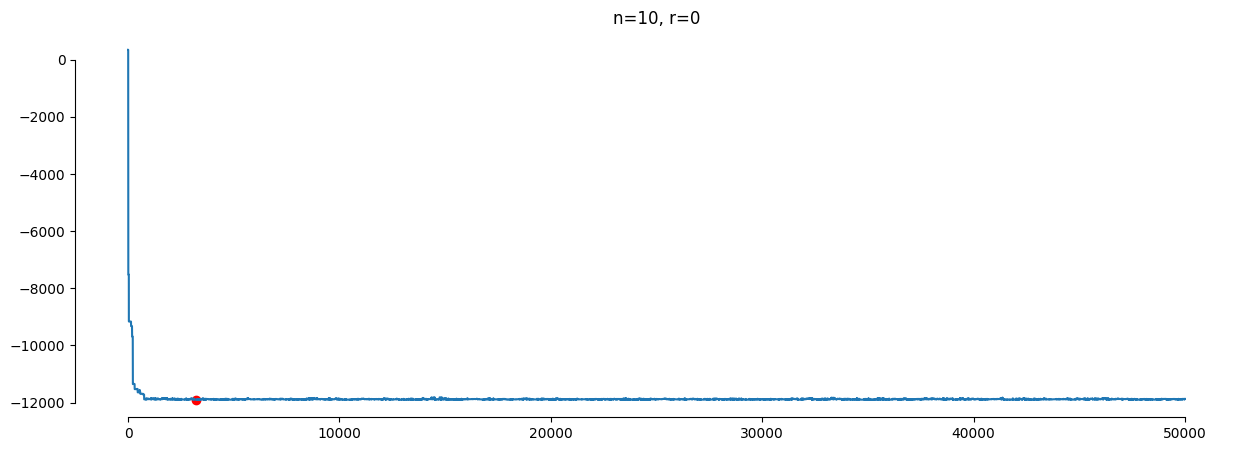

In [6]:
Nini = 00
plt.figure(figsize=(15, 5))

#Define figure size in cm                                                                           
Extensions=['.png']

#Fonts and sizes                                                                                    
size_axis=7;size_ticks=6;size_title=5
line_w=1;marker_s=3 #width and marker size                                                           
plt.title( 'n=' + str(n) +', r=' + str(realization))
plt.plot(trace.t[trace.t > Nini], trace.H[trace.t > Nini])
plt.scatter(minrow['t'], minH,color='r')
sns.despine(trim=True)

#Name_figure='Energy_' + function + '_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)

#for ext in Extensions:
#        plt.savefig('../results/' + Name_figure + ext,dpi=300)

 
plt.show()

6400
4800
0.7375


,x,y,z,rep,noise,z_noise,zmodel,ybms
0,0.0000,0.0000,0.000000,10,0.001159,0.001159,0.007977,0.000000
1,0.0000,0.0125,0.000000,10,-0.013802,-0.013802,0.007563,0.000000
2,0.0000,0.0250,0.000000,10,0.010916,0.010916,0.007163,0.000000
3,0.0000,0.0375,0.000000,10,0.008153,0.008153,0.006777,0.000000
4,0.0000,0.0500,0.000000,10,-0.000131,-0.000131,0.006404,0.000000
...,...,...,...,...,...,...,...,...
6395,0.9875,0.9375,0.888559,10,0.008890,0.897449,0.912117,0.888000
6396,0.9875,0.9500,0.885730,10,0.005471,0.891200,0.909782,0.885266
6397,0.9875,0.9625,0.882865,10,0.031523,0.914388,0.907430,0.882504
6398,0.9875,0.9750,0.879967,10,0.012454,0.892421,0.905061,0.879715


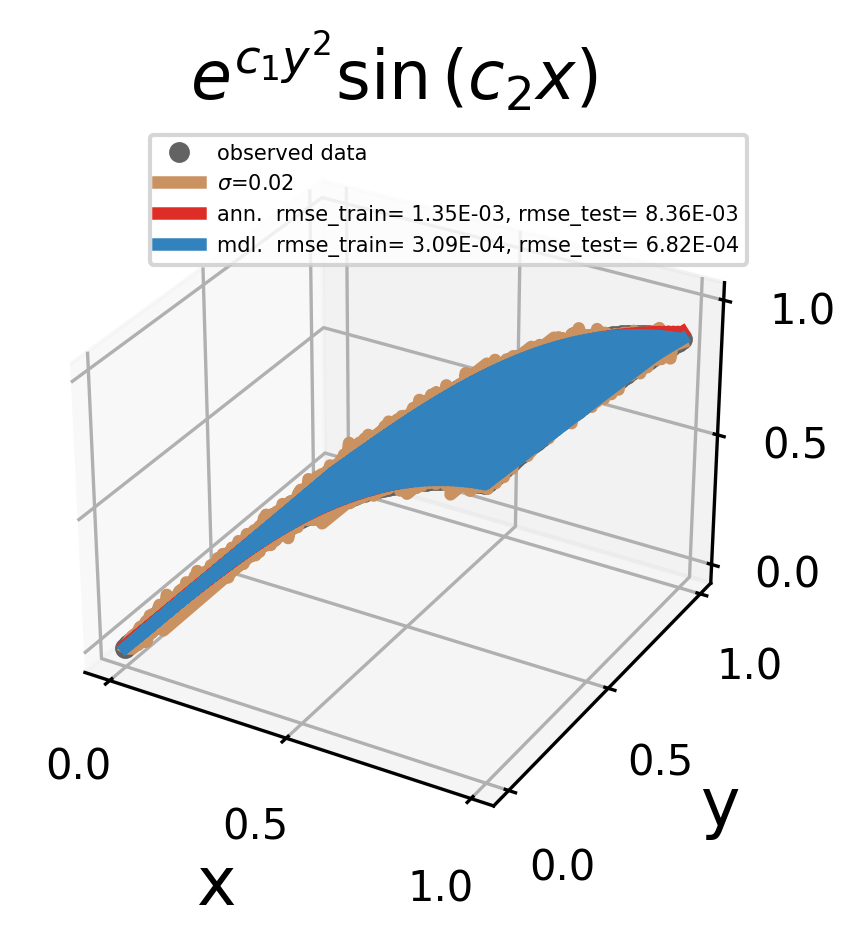

(sin((_a1_ * x)) * exp((_a7_ * (y ** 2)))) {'d0': {'_a1_': 1.5011881640755074, '_a7_': -0.13070090552400407, '_a0_': 1.0, '_a2_': 1.0, '_a3_': 1.0, '_a4_': 1.0, '_a5_': 1.0, '_a6_': 1.0}}


In [8]:
#Validation and train borders
n_points=int(len(dn.index))
print(n_points)
train_fraction=5/8;valid_fraction=1/8;test_fraction=0.2
train_size_ann=int(n_points*train_fraction)
train_size_bms=train_size_ann + int(n_points*valid_fraction)

train_border=dn.loc[train_size_bms-1]['x']
print(train_size_bms)
print(train_border)

dplot = deepcopy(dn)

dplot['ybms'] = t.predict(x)
display(dplot)

#Save dataframe?
dplot.to_csv('test.csv')

#display(dplot.loc[train_size-1:])

rmse_nn_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['zmodel'],dplot.loc[:train_size_bms -1]['z'])
rmse_nn_test=root_mean_squared_error(dplot.loc[train_size_bms-1:]['zmodel'],dplot.loc[train_size_bms -1:]['z'])
rmse_mdl_train=root_mean_squared_error(dplot.loc[:train_size_bms-1]['ybms'],dn.loc[:train_size_bms-1]['z'])
rmse_mdl_test =root_mean_squared_error(dplot.loc[train_size_bms-1:]['ybms'],dn.loc[train_size_bms-1:]['z'])

 
#Define figure size in cm                                                                           
cm = 1/2.54 #convert inch to cm                                                                     
width = 10*cm; height=8*cm

Extensions=['.png']  
#Text and figure sizes  
#--------------------------------
size_axis=16;size_ticks=14;size_title=16
line_w=3;marker_s=8
size_legend=5
#--------------------------------

#ticks, limits and titles
#--------------------------------------------------------------------------------------------
ticks={1:{'x':[0, 0.5, 1], 'y':[ -3, 0, 3, 6.0]}, 5:{'x':[-1, 0, 1], 'y':[-0.75,-0.5, -0.25]}, 
       7:{'x':[0,1,2,], 'y': [1,2,3]}, 8:{'x':[0,2,4], 'y':[0, 1, 2]}, 
       10:{'x':[0,0.5,1], 'y':[0,0.5,1], 'z':[0,0.5,1] } }

limits={1:{'x':[-1.1,1.1], 'y':[-3.25, 8]}, 5:{'x':[-1.2,1.2], 'y':[-0.8,-0.2]}, 
        7:{'x':[-0.1,2.1], 'y': [0.4,3.1]}, 8:{'x':[-0.1,4.2], 'y':[-0.1, 2.5]}, 
        10:{'x':[-0.1,1.1], 'y':[-0.1,1.1], 'z':[-0.1,1.1] } } 

#nguyen title dict
titles={1: r'$y_1=3.39 x^3 + 2.12 x^2 +1.78x$',
        5: r'$y_5=\sin(x^2) \cos(x)$', 
        7: r'$y_7=\log(x+1.4) + \log(x^2 + 1.3)$',
        8: r'$y_8=\sqrt{1.23x}$',
        10:r'$y_{10}=\sin(1.5x) \cos(0.5y)$' }
#--------------------------------------------------------------------------------------------

fig=figure(figsize=(width,height), dpi=300)    

if n==10:
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(dn.x, dn.y, dn.z, '.', markersize=marker_s, color=color_data, label='observed data')
    ax.plot(dn.x, dn.y, dn.z_noise, linewidth=line_w,color=color_noise, label=r'$\sigma$='+str(sigma))
    ax.plot(dn.x, dn.y, dn.zmodel,linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_nn_train, rmse_nn_test)) 
    ax.plot(dplot.x, dplot.y, dplot.ybms, linewidth=line_w,color=color_bms,label='mdl.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_mdl_train, rmse_mdl_test))
    ax.set_xticks(ticks[n]['x']);ax.set_yticks(ticks[n]['y']);ax.set_zticks(ticks[n]['z'])
    ax.set_xlabel('x',fontsize=size_axis);ax.set_ylabel('y',fontsize=size_axis);ax.set_zlabel('z',fontsize=size_axis)
    #plt.rcParams["axes3d.mouserotationstyle"] = 'arcball' # or 'cube'

else:
    plt.plot(dn['x'], dn['z'],'.', markersize=marker_s, color=color_data, label='observed data')
    plt.plot(dn['x'], dn['zmodel'],linewidth=line_w, color=color_ann, label='ann.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_nn_train, rmse_nn_test)) 
    plt.plot(dplot.x, dplot.ybms, linewidth=line_w,color=color_bms,label='mdl.  rmse_train= %.2E, rmse_test= %.2E' % ( rmse_mdl_train, rmse_mdl_test))
    plt.plot(dn['x'], dn['z_noise'],linewidth=line_w, markersize=marker_s, color=color_noise,label=r'$\sigma$='+str(sigma)) 

    train_size=60
    train_border=dn.loc[train_size-1]['x']
    plt.axvline(x=train_border,linestyle='--',linewidth=line_w, color='k')
    plt.xlabel('x',fontsize=size_axis);plt.ylabel('y',fontsize=size_axis)
    plt.xticks(ticks[n]['x'], fontsize=size_ticks);plt.yticks(ticks[n]['y'], fontsize=size_ticks)
    plt.xlim(limits[n]['x'][0], limits[n]['x'][1]);plt.ylim(limits[n]['y'][0], limits[n]['y'][1])
    

plt.legend(loc='best', fontsize=size_legend)
plt.title('$%s$' % t.latex(),fontsize=size_title)
#plt.title(titles[10],fontsize=size_title)
    
Name_figure='prediction_'  + 'nguyen_n_' + str(n) + '_sigma_' + str(sigma) + '_r_'  + str(realization) + '_par_' + str(NPAR)
    
for ext in Extensions:
        plt.savefig('../../results/' + Name_figure +ext,dpi=300)

plt.show()
plt.rcParams["axes3d.mouserotationstyle"] = 'arcball' # or 'cube'
print(t,t.par_values)

In [ ]:
t.par_values


In [ ]:
print(len(t.par_values['d0']))

a0=t.par_values['d0']['_a0_']
a1=t.par_values['d0']['_a1_']
a2=t.par_values['d0']['_a2_']
a3=t.par_values['d0']['_a3_']
a4=t.par_values['d0']['_a4_']
a5=t.par_values['d0']['_a5_']
a6=t.par_values['d0']['_a6_']
a7=t.par_values['d0']['_a7_']
print(a1, a2, a3)
    